# Local environments and electronic structure

Two questions a composition vector provably cannot answer.

**What does an atom's neighbourhood look like?** Octahedral or tetrahedral,
four-fold or six-fold, rigid or distorted. Two polymorphs have identical
compositions and can differ entirely in coordination — which is why `X` is
silent on the question and `mv.env` exists.

**What can the electrons do?** Almost every functional property is downstream
of the band structure, and a band structure is neither one number per material
nor one number per atom. It gets its own axis, and `mv.elec` builds it.

Both namespaces put results where their *shape* belongs, which is the thread
running through all of matverse: per-atom to the sites axis, per-band to the
bands axis, per-material scalars back to `obs` where a screen can reach them.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

🔬 Starting plot initialization...
🧪 Calculators available: 6
    • emt — EMT (LGPL-2.1)
    • lj — Lennard-Jones (LGPL-2.1)
    • mace-mpa — mace-mpa (unstated)
    • mace-omat — mace-omat (unstated)
    • sevennet — sevennet (unstated)
    • chgnet — chgnet (unstated)


🖥️ NVIDIA CUDA GPUs: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3 — 79.1 GB, compute 9.0

                   __
   ____ ___  ____ _/ /__   _____  _____________
  / __ `__ \/ __ `/ __/ | / / _ \/ ___/ ___/ _ \
 / / / / / / /_/ / /_ | |/ /  __/ /  (__  )  __/
/_/ /_/ /_/\__,_/\__/ |___/\___/_/  /____/\___/

🔖 Version: 0.1.71   🧮 Functions: 212   📚 Tutorials: https://matverse.readthedocs.io/
✅ set_style complete.



That report is the point of `mv.pl.set_style` doing more than set rcParams:
matverse ships one working calculator and dispatches the rest to whatever you
installed, so *which levels of theory can this machine run* has a different
answer on every machine — and it decides what the session can do.

## Loading a dataset

Olivine LiFePO₄, the cathode of [Padhi et al.
(1997)](https://doi.org/10.1149/1.1837571). Its structure is the textbook case
for the first half of this page: a framework of LiO₆ and FeO₆ octahedra with
rigid PO₄ tetrahedra wedged between them.

In [2]:
md = mv.datasets.load("battery_cathodes")[:1].copy()
mv.pp.describe(md)

md.obs[["name", "formula", "spacegroup", "nsites"]]

,name,formula,spacegroup,nsites
0,LiFePO4,LiFePO4,P2_1/c,28


## Coordination: the sites axis again

A coordination number is one value per atom, so it belongs on the axis whose
rows are atoms — the same object `mv.calc.forces` writes into.

In [3]:
sites = mv.multi.sites(md)
mv.env.coordination(md, sites)

sites.obs.groupby("element", observed=True)[
    "coordination_number"].mean().round(2)

element
Fe    6.0
Li    6.0
O     4.0
P     4.0
Name: coordination_number, dtype: float64

**Li 6, Fe 6, P 4, O 4** — the published olivine coordination, recovered from
the coordinates alone.

Which algorithm produced those numbers is recorded next to them, and that is
not bookkeeping. Near-neighbour algorithms disagree: CrystalNN and
MinimumDistanceNN routinely differ by one or two on the same site, so a
coordination number without its strategy is not reproducible.

In [4]:
mv.env.STRATEGIES

{'crystalnn': 'CrystalNN — Voronoi with a solid-angle cutoff tuned on the Materials Project; the general-purpose default',
 'voronoi': 'VoronoiNN — raw Voronoi solid angles, no chemistry-aware weighting',
 'minimum_distance': 'MinimumDistanceNN — everything within a tolerance of the shortest bond; fast and crude',
 'econ': 'EconNN — the effective coordination number of Hoppe (1979), which weights neighbours continuously rather than counting them',
 'brunner': 'BrunnerNN_real — the largest gap in the distance histogram'}

In [5]:
other = mv.multi.sites(md)
mv.env.coordination(md, other, strategy="minimum_distance")

pd.DataFrame({
    "crystalnn": sites.obs.groupby("element", observed=True)[
        "coordination_number"].mean(),
    "minimum_distance": other.obs.groupby("element", observed=True)[
        "coordination_number"].mean(),
}).round(2)

,crystalnn,minimum_distance
element,,
Fe,6.0,5.0
Li,6.0,6.0
O,4.0,1.0
P,4.0,4.0


## A number is not a shape

Six-fold coordination can be octahedral, trigonal prismatic, or a badly
distorted octahedron, and those are different materials. `mv.env.chemenv` fits
model polyhedra and reports the **continuous symmetry measure**: zero is
perfect, and a large value means "distorted" rather than the name it was
given.

In [6]:
mv.env.chemenv(md, sites)

sites.obs[["element", "environment", "environment_csm"]].head(12).round(2)

,element,environment,environment_csm
0:0,Li,O:6,2.07
0:1,Li,O:6,2.05
0:2,Li,O:6,2.08
0:3,Li,O:6,2.04
0:4,Fe,O:6,2.37
0:5,Fe,O:6,2.37
0:6,Fe,O:6,2.37
0:7,Fe,O:6,2.37
0:8,P,T:4,0.14
0:9,P,T:4,0.14


In [7]:
sites.obs.groupby("element", observed=True)[
    "environment_csm"].mean().round(3)

element
Fe    2.369
Li    2.060
O     2.160
P     0.140
Name: environment_csm, dtype: float64

This is the structural story of an olivine cathode, in one column.

The phosphate tetrahedron comes out at **0.14** — essentially a perfect T:4,
which is what a covalent polyanion is. The metal octahedra come out at
**2.0–2.4**, heavily distorted. That contrast is why LiFePO₄ is thermally
stable and safe while layered oxides are not: the P–O bonds do not let go, and
the framework does not collapse when lithium leaves.

A coordination number of 6 and 4 could not have told you that.

Text(0.5, 1.0, 'rigid phosphate, distorted metal octahedra')

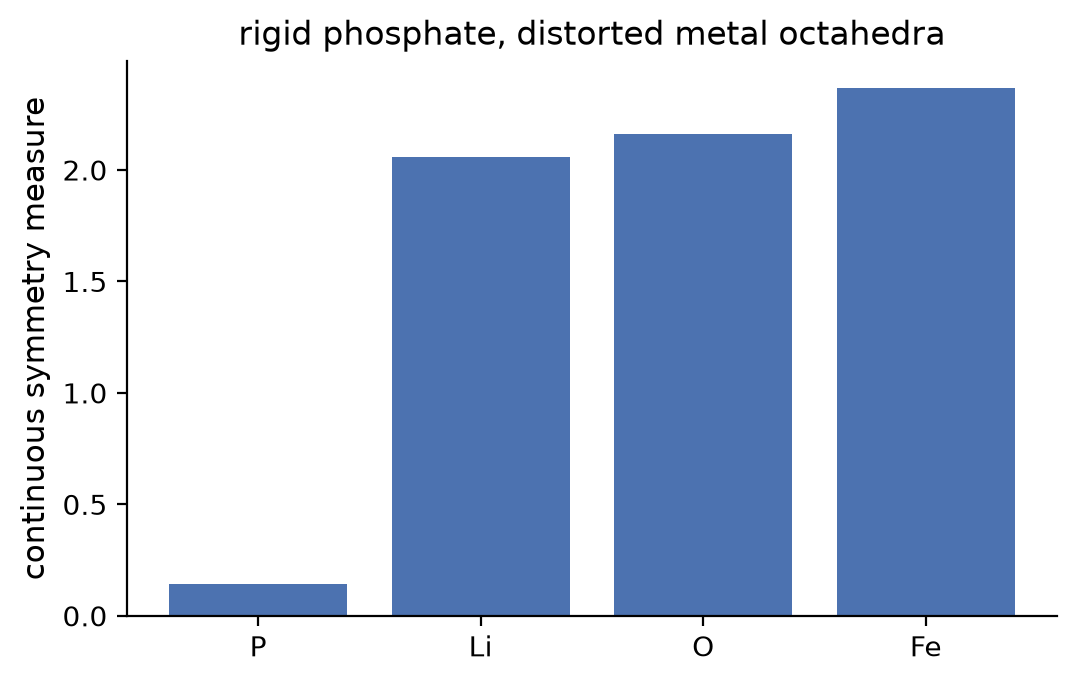

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.6))
by_element = sites.obs.groupby("element", observed=True)["environment_csm"]
order = by_element.mean().sort_values()
ax.bar(order.index, order.to_numpy(), color="#4c72b0")
ax.set_ylabel("continuous symmetry measure")
ax.set_title("rigid phosphate, distorted metal octahedra")

## The bond network belongs in `obsp`

Connectivity over the atoms is a graph over the rows of the sites object, and
AnnData already has a slot for exactly that — the same one a kNN graph occupies
in single-cell analysis.

In [9]:
mv.env.bonds(md, sites)

sites.obsp["bonds"].shape, sites.obsp["bonds"].nnz

((28, 28), 128)

In [10]:
degree = np.asarray(sites.obsp["bonds"].sum(axis=1)).ravel()
np.allclose(degree, sites.obs["coordination_number"].to_numpy(dtype=float))

True

The degree of the graph is the coordination number, which it had better be.

Bonds never cross materials — two atoms in different structures are never
connected — so the matrix is block diagonal and a graph algorithm cannot walk
from one material into another.

## Back to the material axis

Per-atom detail stays on the sites object; a screen needs a summary.

In [11]:
mv.env.summarise(sites, md)

md.obs[["name", "mean_coordination", "min_coordination",
        "max_coordination", "coordination_spread"]].round(2)

,name,mean_coordination,min_coordination,max_coordination,coordination_spread
0,LiFePO4,4.57,4.0,6.0,2.0


In [12]:
mv.screen.filter(md, max_coordination__ge=6.0, name="has_octahedra")
md.obs[["name", "has_octahedra"]]

,name,has_octahedra
0,LiFePO4,True


`coordination_spread` is the one worth screening on: zero means every atom sits
in the same environment, which is what a high-symmetry structure looks like
from the inside.

## Do the polyhedra connect?

`mv.env.chemenv` said each site is an octahedron or a tetrahedron. The next
question is whether those polyhedra join up, and in how many directions — which
is not the same as whether the *bonds* do.

In [13]:
mv.env.connectivity(md)
md.obs[["name", "n_polyhedral_components", "connectivity_dimension",
        "largest_component_sites", "is_3d_connected"]]

,name,n_polyhedral_components,connectivity_dimension,largest_component_sites,is_3d_connected
0,LiFePO4,2,3,16,True


For an ion conductor this is the question. A framework whose octahedra share
corners in only two directions cannot conduct in the third, however low the
individual hop barrier is — and a hop barrier is the expensive thing to compute.

```{warning}
This function and `mv.env.chemenv` both had an order-dependence bug until
v0.1.26, and it is worth knowing about because of how it hid.

`LocalGeometryFinder` keeps state that `setup_structure` does not clear. Reusing
one across a dataset returned **empty** environments for every material after
the first — as a blank string, not an error. Nothing caught it because every
test and every notebook cell used a single-material dataset. Both functions now
build a fresh finder per structure, and the test suite pins the answer against
dataset order.
```

## The same graph, asked a global question

Coordination is local: how many neighbours does this atom have. The bond graph
also answers something the local view cannot — whether the structure holds
together in three directions, in two, in one, or not at all. That is the
difference between a framework, a layered material you can exfoliate, a chain
compound and a molecular crystal.

`mv.prop.dimensionality` is the archetypal thing `X` cannot tell you. Graphite
and diamond have the same composition matrix, the same `var`, and the same
element counts. One is layers held by van der Waals forces; the other is the
hardest material in common use.

In [14]:
from pymatgen.core import Lattice, Structure

graphite = Structure(Lattice.hexagonal(2.46, 6.70), ["C"] * 4,
                     [[0, 0, 0], [1/3, 2/3, 0], [0, 0, 0.5], [2/3, 1/3, 0.5]])
diamond = Structure(Lattice.cubic(3.567), ["C"] * 8,
                    [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0],
                     [.25, .25, .25], [.25, .75, .75],
                     [.75, .25, .75], [.75, .75, .25]])
mos2 = Structure(Lattice.hexagonal(3.16, 12.3),
                 ["Mo", "Mo", "S", "S", "S", "S"],
                 [[1/3, 2/3, 0.25], [2/3, 1/3, 0.75],
                  [2/3, 1/3, 0.371], [1/3, 2/3, 0.629],
                  [1/3, 2/3, 0.871], [2/3, 1/3, 0.129]])

carbon = mv.data.from_structures([graphite, diamond, mos2])
mv.pp.describe(carbon)
mv.prop.dimensionality(carbon)

carbon.obs[["formula", "dimensionality", "n_components", "is_layered",
            "density"]].round(2)

,formula,dimensionality,n_components,is_layered,density
0,C,2,2,True,2.27
1,C,3,1,False,3.52
2,MoS2,2,2,True,5.00


Graphite 2D, diamond 3D, MoS2 2D — and `n_components` counts two layers per
cell for both of the layered ones.

The two carbons differ in density, so density is *a* signal, but it is the kind
that fails on the next pair. Dimensionality is the property itself.

A screen asks for it directly:

In [15]:
mv.screen.filter(carbon, dimensionality__eq=2, name="exfoliable")
carbon.obs[["formula", "exfoliable", "dimensionality_strategy"]]

,formula,exfoliable,dimensionality_strategy
0,C,True,crystalnn
1,C,False,crystalnn
2,MoS2,True,crystalnn


`dimensionality_strategy` is recorded next to the answer for the same reason
`coordination_strategy` was. The near-neighbour algorithms disagree, and here
the disagreement is sharper than it was for a coordination number: the
classification turns entirely on whether a long contact counts as a bond, which
is precisely what a van der Waals gap is. A dimensionality without its strategy
is not a reproducible result.

## Electronic structure

`mv.elec` starts where a band structure starts — the path through the Brillouin
zone that it is plotted along.

In [16]:
metals = mv.datasets.metals(["Cu", "Al"])
mv.pp.describe(metals)
mv.elec.kpath(metals, line_density=8)

metals.obs[["name", "kpath_labels", "n_kpoints", "kpath_type"]]

,name,kpath_labels,n_kpoints,kpath_type
0,Cu,\Gamma - X - W - K - L - U,102,setyawan_curtarolo
1,Al,\Gamma - X - W - K - L - U,95,setyawan_curtarolo


Γ–X–W–K–L–U, the standard fcc path. Note that Cu and Al get **different numbers
of k-points** — the path depends on the lattice, and two materials in one
dataset generally do not share one.

That raggedness is the design problem the bands axis has to solve.

```{note}
Setyawan–Curtarolo and Hinuma disagree on several Bravais lattices, so which
convention was used is recorded. A band structure whose path convention is
unstated is not reproducible.
```

### A real band structure, without a DFT code

The rest of this section needs band energies. Rather than ship a fixture, we
compute them: nearest-neighbour tight binding on an fcc lattice is a textbook
model with a closed-form dispersion, and evaluating it on the real k-path gives
a real band structure of a real (if simple) Hamiltonian.

In [17]:
from pymatgen.electronic_structure.bandstructure import BandStructureSymmLine
from pymatgen.electronic_structure.core import Spin
from pymatgen.symmetry.bandstructure import HighSymmKpath


def tight_binding(structure, n_bands=4, spacing=3.0, t=1.0):
    """E(k) = -2t [cos kx + cos ky + cos kz], the fcc nearest-neighbour band."""
    path = HighSymmKpath(structure)
    kpoints, _ = path.get_kpoints(line_density=8, coords_are_cartesian=False)
    k = np.asarray(kpoints, dtype=float)
    dispersion = -2.0 * t * (np.cos(2 * np.pi * k[:, 0])
                             + np.cos(2 * np.pi * k[:, 1])
                             + np.cos(2 * np.pi * k[:, 2]))
    rows = [dispersion + spacing * b - spacing * (n_bands // 2)
            for b in range(n_bands)]
    return BandStructureSymmLine(
        kpoints, {Spin.up: np.vstack(rows)},
        structure.lattice.reciprocal_lattice, efermi=0.0,
        labels_dict=dict(path.kpath["kpoints"]), structure=structure)


computed = [tight_binding(s) for s in mv.structures(metals)]
bands = mv.elec.bands(metals, computed, level="tb", n_points=200)
bands

AnnData object with n_obs × n_vars = 8 × 200
    obs: 'material', 'material_index', 'spin', 'band_index', 'band_minimum', 'band_maximum', 'band_width', 'crosses_fermi'
    var: 'path_fraction'
    uns: 'matverse_axis', 'provenance', 'bands'
    layers: None (.X)

**Bands × k-points.** One row per band per spin per material, energies along a
shared path coordinate — structurally a cells × genes matrix, which is why
everything written for that shape applies here without modification.

In [18]:
bands.obs[["material", "spin", "band_index", "band_minimum",
           "band_maximum", "band_width", "crosses_fermi"]].round(3)

,material,spin,band_index,band_minimum,band_maximum,band_width,crosses_fermi
0:up:0,0,up,0,-12.0,0.0,12.0,False
0:up:1,0,up,1,-9.0,3.0,12.0,True
0:up:2,0,up,2,-6.0,6.0,12.0,True
0:up:3,0,up,3,-3.0,9.0,12.0,True
1:up:0,1,up,0,-12.0,0.0,12.0,False
1:up:1,1,up,1,-9.0,3.0,12.0,True
1:up:2,1,up,2,-6.0,6.0,12.0,True
1:up:3,1,up,3,-3.0,9.0,12.0,True


In [19]:
bands.var.head()

,path_fraction
k0,0.000000
k1,0.005025
k2,0.010050
k3,0.015075
k4,0.020101


Two things about the axis are worth reading carefully.

Energies are **relative to the Fermi level** — zero is E_F everywhere on this
object — because an absolute eigenvalue means nothing across codes, or even
across two runs of one code.

The abscissa is **fraction along each material's own path**, not a wavevector.
Cu's 102 k-points and Al's 95 are resampled onto a common 200-point coordinate,
which is the same move that puts two diffraction patterns on one 2θ grid: a
matrix has to have a shared column axis before it can be a matrix. Read it as a
path fraction and never as k.

Text(0.5, 1.0, 'tight-binding bands: both metals cross the Fermi level')

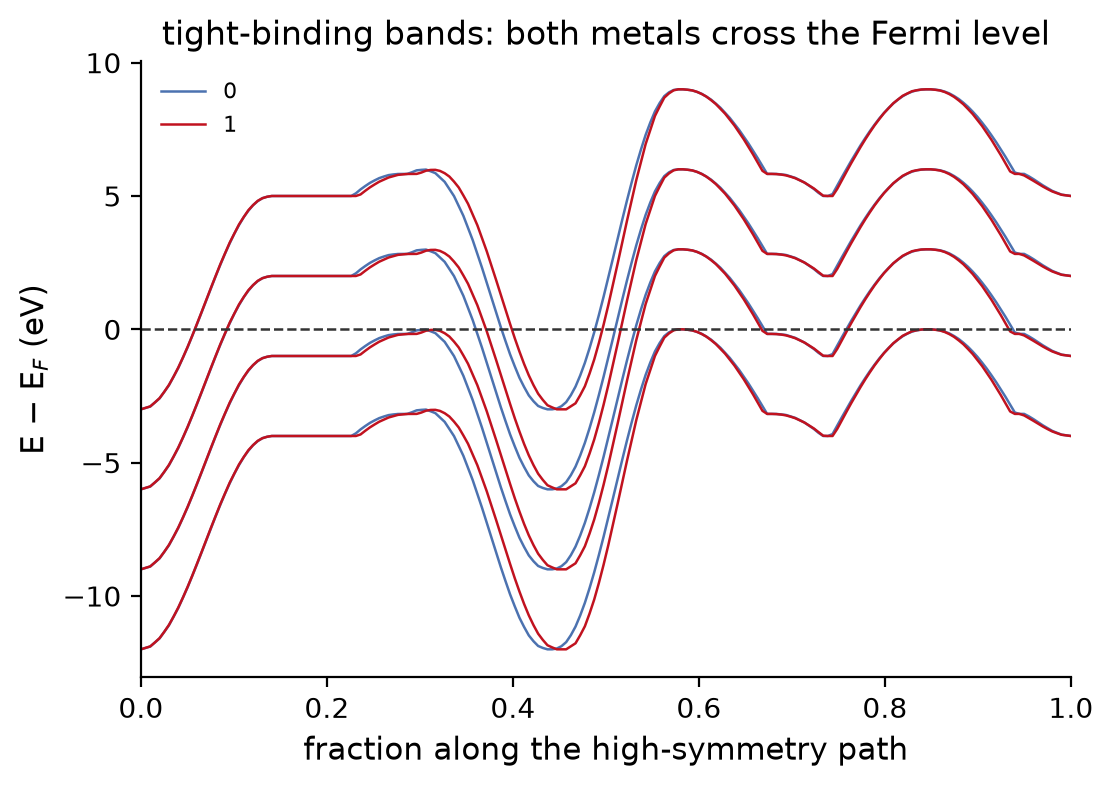

In [20]:
ax = mv.pl.bands(bands)
ax.set_title("tight-binding bands: both metals cross the Fermi level")

## What the bands say

Scalars derived from the bands land back on the material axis — the same move
`mv.multi.aggregate` makes for per-atom data.

In [21]:
mv.elec.band_features(bands, metals, level="tb")

metals.obs[["name", "band_gap_tb", "vbm_tb", "cbm_tb",
            "is_direct_tb", "is_metal_tb", "n_bands_tb"]].round(3)

,name,band_gap_tb,vbm_tb,cbm_tb,is_direct_tb,is_metal_tb,n_bands_tb
0,Cu,0.0,0.0,NaN,False,True,4
1,Al,0.0,0.0,NaN,False,True,4


Metals, gap zero. Correct: two of the four bands cross the Fermi level, and a
material with any band crossing E_F is a metal — not a semiconductor with a
negative gap, which is what a naive VBM-minus-CBM would report.

Build a gapped model and the same function finds the gap it was given:

In [22]:
def semiconductor(structure, gap=1.7, spacing=2.0, n_each=2):
    """Valence bands pushed to touch 0; conduction bands pushed to touch gap."""
    path = HighSymmKpath(structure)
    kpoints, _ = path.get_kpoints(line_density=8, coords_are_cartesian=False)
    k = np.asarray(kpoints, dtype=float)
    d = -2.0 * (np.cos(2 * np.pi * k[:, 0]) + np.cos(2 * np.pi * k[:, 1])
                + np.cos(2 * np.pi * k[:, 2]))

    rows = [d - d.max() - spacing * b for b in range(n_each)]
    rows += [-d + d.max() + gap + spacing * b for b in range(n_each)]
    return BandStructureSymmLine(
        kpoints, {Spin.up: np.vstack(rows)},
        structure.lattice.reciprocal_lattice, efermi=0.0,
        labels_dict=dict(path.kpath["kpoints"]), structure=structure)


gapped = mv.elec.bands(metals, [semiconductor(s)
                                for s in mv.structures(metals)],
                       level="model")
mv.elec.band_features(gapped, metals, level="model")

metals.obs[["name", "band_gap_model", "vbm_model", "cbm_model",
            "is_direct_model", "is_metal_model"]].round(3)

,name,band_gap_model,vbm_model,cbm_model,is_direct_model,is_metal_model
0,Cu,1.7,0.0,1.7,True,False
1,Al,1.7,0.0,1.7,True,False


1.70 eV, which is exactly what the model was built with, and **direct** —
because inverting the conduction dispersion puts its minimum at the same
k-point as the valence maximum. Directness is a k-point comparison, not a
property of the gap size, and it decides whether a material can absorb light
efficiently.

```{warning}
Semilocal DFT underestimates gaps by roughly half. `band_features` reports what
the bands say and does not correct them — the **level name** is what tells a
later reader whether a correction is needed, which is why `band_gap_pbe` and
`band_gap_hse06` are different columns rather than one column with a footnote.
```

## From a real DFT run

With actual output files the whole section above is two calls:

```python
mv.dft.write_inputs(md, 'runs/', preset='bands')
# ... the queue ...
bands = mv.elec.read_bands(md, 'runs/', level='pbe')
mv.elec.band_features(bands, md, level='pbe')
```

A run that produced no parseable band structure becomes a missing row with the
reason in `obs['band_error_pbe']`, never a silently dropped material.

### Density of states, as a fingerprint

`mv.dft.read_dos` puts a DOS on a shared energy grid;
`mv.elec.dos_fingerprint` reduces it to a fixed-length descriptor so two
electronic structures can be compared with a distance rather than by eye.

```python
mv.dft.read_dos(md, 'runs/', level='pbe')
mv.elec.dos_fingerprint(md, level='pbe', window=5.0, n_bins=32)
mv.feat.similarity(md, block='dos_fingerprint_pbe')
```

Binned over a window around E_F, because everything several eV away is deep
valence structure that no property depends on and would swamp the part that
does.

### Bonding analysis

`mv.elec.cohp` reads LOBSTER's crystal orbital Hamilton populations — negative
is bonding, positive antibonding, and the magnitude is a bond strength in eV.
It is the closest thing electronic structure theory offers to a bond order you
can screen on.

```python
mv.elec.cohp(md, 'lobster_runs/', level='pbe')
mv.screen.filter(md, icohp_min_pbe__lt=-2.0)     # at least one strong bond
```

### Transport

`mv.elec.transport` wants BoltzTraP2, which links against netCDF and does not
build from a wheel everywhere.

In [23]:
try:
    mv.elec.transport(metals, bands, level="tb")
except (ImportError, NotImplementedError) as exc:
    print(f"{type(exc).__name__}: {exc}")

ImportError: mv.elec.transport needs BoltzTraP2, which links against netCDF and often will not build from a wheel. Try `conda install -c conda-forge boltztrap2` — note conda-forge carries it only up to a Python 3.10 build. Or read the band edges off mv.elec.band_features and estimate the Seebeck coefficient yourself.


It names the install rather than returning zeros — and the docstring says why
the Seebeck coefficient is the number to trust: the conductivity comes out as
**σ/τ**, because the constant relaxation time approximation cannot supply τ.
Multiplying by a guessed τ is how thermoelectric screens produce figures of
merit that do not survive measurement.

## What both objects remember

In [24]:
for step in mv.provenance(sites):
    print(step)

multi.sites(source='input', n_materials=1)
env.coordination(strategy='crystalnn', source='input')
env.chemenv(source='input', max_csm=8.0)
env.bonds(strategy='crystalnn', source='input')


```{seealso}
[Chemical space](chemical_space.ipynb) is the composition side of the same
question — and the reason this page exists is everything composition cannot
reach. [Beyond one number](beyond_one_number.ipynb) introduces the sites axis
that `mv.env` writes into.
```

## How sure is a coordination number?

`mv.env.coordination` returns an integer. Sometimes that integer is a fact and
sometimes it is a judgement call, and nothing about the integer says which.

`mv.env.voronoi` returns the evidence instead. Every site has more Voronoi
neighbours than bonds, each face carrying a solid angle normalised so the
largest is 1:

In [25]:
from pymatgen.core import Lattice, Structure

rocksalt = Structure.from_spacegroup("Fm-3m", Lattice.cubic(5.64),
                                     ["Na", "Cl"], [[0, 0, 0], [.5, .5, .5]])
rutile = Structure.from_spacegroup(
    "P4_2/mnm", Lattice.tetragonal(4.594, 2.959), ["Ti", "O"],
    [[0, 0, 0], [0.305, 0.305, 0]])

vor = mv.data.from_structures([rocksalt, rutile])
vor.obs_names = ["NaCl", "TiO2"]
vor_sites = mv.multi.sites(vor)
mv.env.voronoi(vor, vor_sites)

vor_sites.obs[["element", "voronoi_faces", "voronoi_coordination",
               "voronoi_margin"]].head(10)

,element,voronoi_faces,voronoi_coordination,voronoi_margin
NaCl:0,Na,6.0,6.0,1.000000
NaCl:1,Na,6.0,6.0,1.000000
NaCl:2,Na,6.0,6.0,1.000000
NaCl:3,Na,6.0,6.0,1.000000
NaCl:4,Cl,6.0,6.0,1.000000
NaCl:5,Cl,6.0,6.0,1.000000
NaCl:6,Cl,6.0,6.0,1.000000
NaCl:7,Cl,6.0,6.0,1.000000
TiO2:0,Ti,10.0,6.0,0.978383
TiO2:1,Ti,10.0,6.0,0.978383


Sodium gets six faces and six neighbours, every weight 1.0 — nothing to decide.
Titanium gets **ten faces and six neighbours**: four at 1.0, two at 0.978, and
four at exactly 0.0. Those extra numbers say more than "six" does. The 4+2 split
is the tetragonal distortion of the TiO₆ octahedron, and the four zeros are
second-shell contacts that are geometric neighbours and not chemical ones.

`voronoi_margin` is the gap between the weakest counted neighbour and the
strongest rejected one. Both of these are 1.0 and 0.978 — wide margins, so the
coordination number is not a judgement call for either. Distort the cell and it
narrows:

In [26]:
awkward = Structure(Lattice.tetragonal(5.64, 5.64), ["Na", "Cl", "Na", "Cl"],
                    [[0, 0, 0], [.5, .5, .5], [.5, .5, 0], [0, 0, .5]])
odd = mv.data.from_structures([awkward])
odd_sites = mv.multi.sites(odd)
mv.env.voronoi(odd, odd_sites)

print(f"rocksalt margin: {vor_sites.obs['voronoi_margin'].iloc[0]:.3f}")
print(f"distorted margin: {odd_sites.obs['voronoi_margin'].iloc[0]:.3f}")

rocksalt margin: 1.000
distorted margin: 0.576


0.58 against 1.00. That is the column to sort on when auditing coordination
numbers across a screen: a small margin flags the rows where a different
algorithm would plausibly disagree, which is exactly where you want to look
before trusting a number rather than after.

## Who counts as a neighbour?

`mv.env.coordination` decides that from geometry — a distance, a Voronoi solid
angle, a bond-valence sum. `mv.env.lobster` decides it from the calculated
bonding: two atoms are neighbours when there is an integrated crystal orbital
Hamilton population between them, and not otherwise.

On rocksalt the two agree, which is the baseline worth establishing first:

In [27]:
from pymatgen.core import Lattice, Structure
from pymatgen.electronic_structure.cohp import IcohpCollection
from pymatgen.electronic_structure.core import Spin

salt = Structure.from_spacegroup("Fm-3m", Lattice.cubic(5.64), ["Na", "Cl"],
                                 [[0, 0, 0], [.5, .5, .5]])

def icohp_for(cell, cutoff=3.0, skip=()):
    "An ICOHP list over the neighbours within a cutoff, minus any skipped."
    L, A1, A2, LEN, TR, N, IC = [], [], [], [], [], [], []
    k = 0
    for i, site in enumerate(cell):
        for nb in cell.get_neighbors(site, cutoff):
            if nb.index <= i:
                continue
            if k in skip:
                k += 1
                continue
            k += 1
            L.append(str(k)); A1.append(f"{site.specie.symbol}{i + 1}")
            A2.append(f"{nb.specie.symbol}{nb.index + 1}")
            LEN.append(float(nb.nn_distance))
            TR.append(tuple(int(v) for v in nb.image))
            N.append(1); IC.append({Spin.up: -2.5})
    return IcohpCollection(L, A1, A2, LEN, TR, N, IC, False)

rocksalt = mv.data.from_structures([salt])
rs_sites = mv.multi.sites(rocksalt)
mv.env.lobster(rocksalt, rs_sites, [icohp_for(salt)],
               valences=[1.0] * 4 + [-1.0] * 4)

rs_sites.obs[["element", "lobster_coordination", "lobster_environment"]]

,element,lobster_coordination,lobster_environment
0:0,Na,6.0,O:6
0:1,Na,6.0,O:6
0:2,Na,6.0,O:6
0:3,Na,6.0,O:6
0:4,Cl,6.0,O:6
0:5,Cl,6.0,O:6
0:6,Cl,6.0,O:6
0:7,Cl,6.0,O:6


Six and octahedral for every site, which is what rocksalt is.

Now the case that separates the two criteria. Drop four bonds from the ICOHP
list and change **nothing** about the geometry — the atoms are exactly where
they were:

In [28]:
partial = mv.data.from_structures([salt])
p_sites = mv.multi.sites(partial)
mv.env.lobster(partial, p_sites, [icohp_for(salt, skip=(0, 1, 2, 3))],
               valences=[1.0] * 4 + [-1.0] * 4)

p_sites.obs[["element", "lobster_coordination"]]

,element,lobster_coordination
0:0,Na,2.0
0:1,Na,6.0
0:2,Na,6.0
0:3,Na,6.0
0:4,Cl,6.0
0:5,Cl,5.0
0:6,Cl,5.0
0:7,Cl,4.0


Lower coordination, from an identical structure. A geometric criterion would
still say six at any cutoff, because **the information is not in the geometry** —
a short contact with no bonding is not a bond, and no distance threshold can
know that.

That is the case worth reaching for this function for. Most of the time it will
agree with `mv.env.coordination`, and the times it does not are the times the
geometric answer was wrong.

```{note}
The ICOHP data is an argument, one per row, as an `Icohplist` or
`IcohpCollection` — the same arrangement as the band structures above. Read one
off disk with `pymatgen.io.lobster.Icohplist(filename='ICOHPLIST.lobster')`;
`mv.elec.cohp` does exactly that for the per-material bonding summaries.

`additional_condition` follows LOBSTER's own numbering: 1, the default, keeps
cation–anion bonds only and needs valences, which is what an ionic solid wants.
Pass 0 to keep every bond.
```

## What photoemission actually sees

A measured XPS spectrum looks nothing like a plotted density of states, and the
reason is not broadening. Photoemission sees each orbital through its
**photoionisation cross-section**, and those differ by more than an order of
magnitude between elements and between shells of the same element.

Copper's 3d cross-section is 0.0012 and oxygen's 2p is 0.00006 — a factor of
twenty. Two states contributing equally to the DOS of a copper oxide contribute
twenty-to-one to its photoemission:

In [29]:
import numpy as np
from pymatgen.core import Lattice, Structure
from pymatgen.electronic_structure.core import Orbital, Spin
from pymatgen.electronic_structure.dos import CompleteDos, Dos

energies = np.linspace(-10, 5, 401)
cu_band = np.exp(-0.5 * ((energies + 3.0) / 0.3) ** 2)   # Cu 3d at -3 eV
o_band = np.exp(-0.5 * ((energies + 6.0) / 0.3) ** 2)    # O 2p at -6 eV

cell = Structure(Lattice.cubic(4.2), ["Cu", "O"], [[0, 0, 0], [.5, .5, .5]])
projected = CompleteDos(
    cell, Dos(0.0, energies, {Spin.up: cu_band + o_band}),
    {cell[0]: {Orbital.dxy: {Spin.up: cu_band}},
     cell[1]: {Orbital.px: {Spin.up: o_band}}})

oxide = mv.data.from_structures([cell])
mv.elec.xps(oxide, [projected], level="model")

binding = mv.grid_of(oxide, "xps")
spectrum = oxide.obsm["xps_model"][0]
cu = spectrum[int(np.argmin(abs(binding - 3.0)))]
ox = spectrum[int(np.argmin(abs(binding - 6.0)))]
print(f"equal in the DOS; in the XPS the ratio is {cu / ox:.1f}")

equal in the DOS; in the XPS the ratio is 20.0


Twenty, exactly the ratio of the two cross-sections. The oxygen states are
still there and are nearly invisible.

This is the mistake that makes people distrust their own calculations: they plot
a DOS beside a measured XPS, see a peak in one and not the other, and conclude
the functional is wrong. Often the functional is fine and the oxygen is simply
not being seen.

(0.0, 9.0)

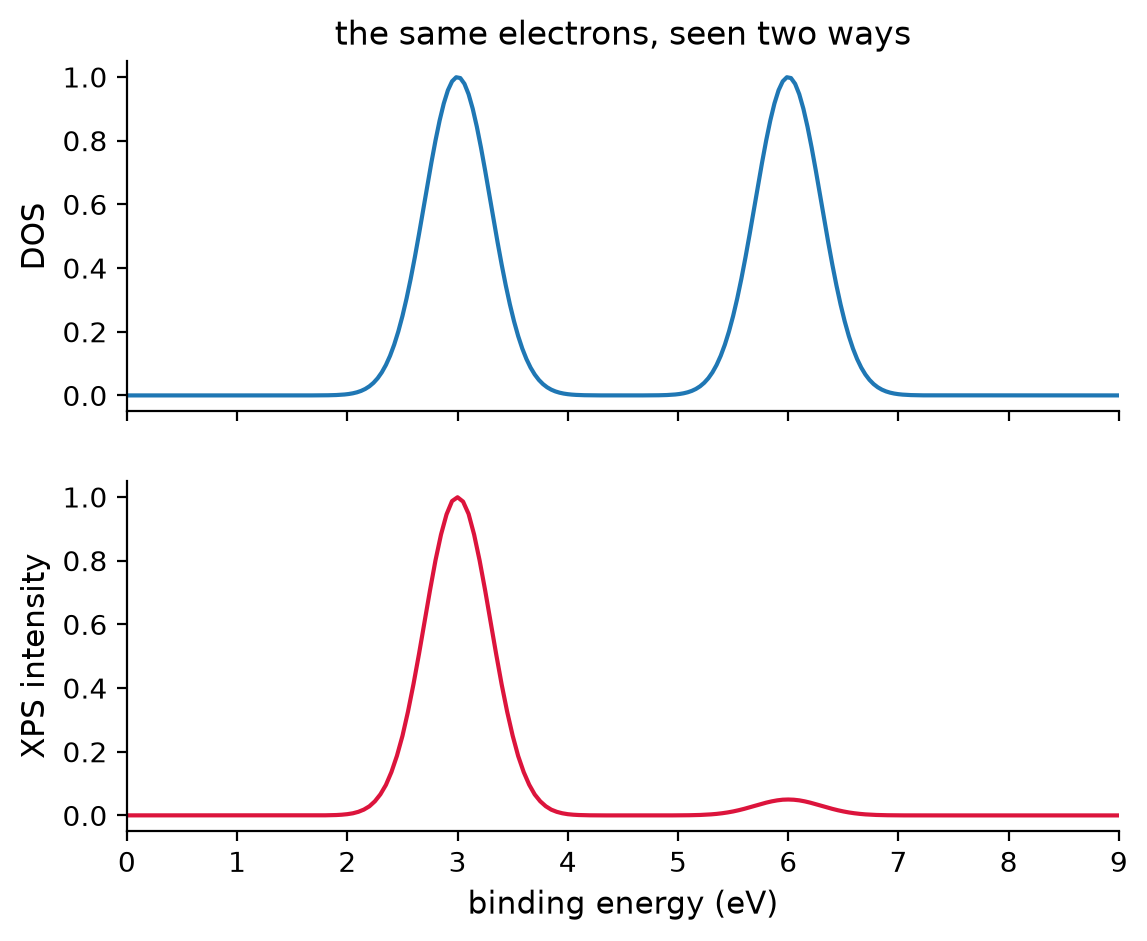

In [30]:
import matplotlib.pyplot as plt

fig, (top, bottom) = plt.subplots(2, 1, figsize=(6.4, 5), sharex=True)
top.plot(-energies, cu_band + o_band, linewidth=1.5)
top.set_ylabel("DOS")
top.set_title("the same electrons, seen two ways")
bottom.plot(binding, spectrum, linewidth=1.5, color="crimson")
bottom.set_ylabel("XPS intensity")
bottom.set_xlabel("binding energy (eV)")
bottom.set_xlim(0, 9)
top.set_xlim(0, 9)

```{note}
**The DOS objects are an argument**, one per row, like the band structures
above — they come from a real calculation, and `mv.dft.read_dos` parses them out
of a directory of vasprun files. The projections have to be present: a total DOS
carries no orbital character, so there is nothing to weight.

The axis is binding energy, so it runs opposite to a DOS. A state 3 eV below the
Fermi level appears at +3 eV.
```